# Desk synthesis — Microstructure Noise / TSRV

Romero (2016) / ZMA05 TSRV on crypto perps (**HL · Deribit · Kraken**).

**Program status (Pass 2.7):** **0 Promote / 5 Hold / 4 Kill** · n_ok=**204** · n_mid=**122** · 34d ETH+BTC+SOL

Hard rule: sized claims only if a **Promote** clears the pre-registered gate. Holds are monitors / research debt — not soft-Promotes.

**SoT:** [`DESK_MEMO.md`](../DESK_MEMO.md) · [`CHAPTER_INDEX.md`](../CHAPTER_INDEX.md)  
**Artifacts:** `out/blocker_close/` · `out/gap_close/` · `out/monte_carlo/` · `out/desk_synthesis/figs/`


## 0. Setup — load Pass 2.6 artifacts (no multi-hour recompute)


In [1]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # research/

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_ratio_hist.png', 'fig_tob_coverage.png', 'fig_tsrv_oos.png', 'signal_board.png']


## 1. Signal board


**Signal board** — `out/desk_synthesis/figs/signal_board.png`

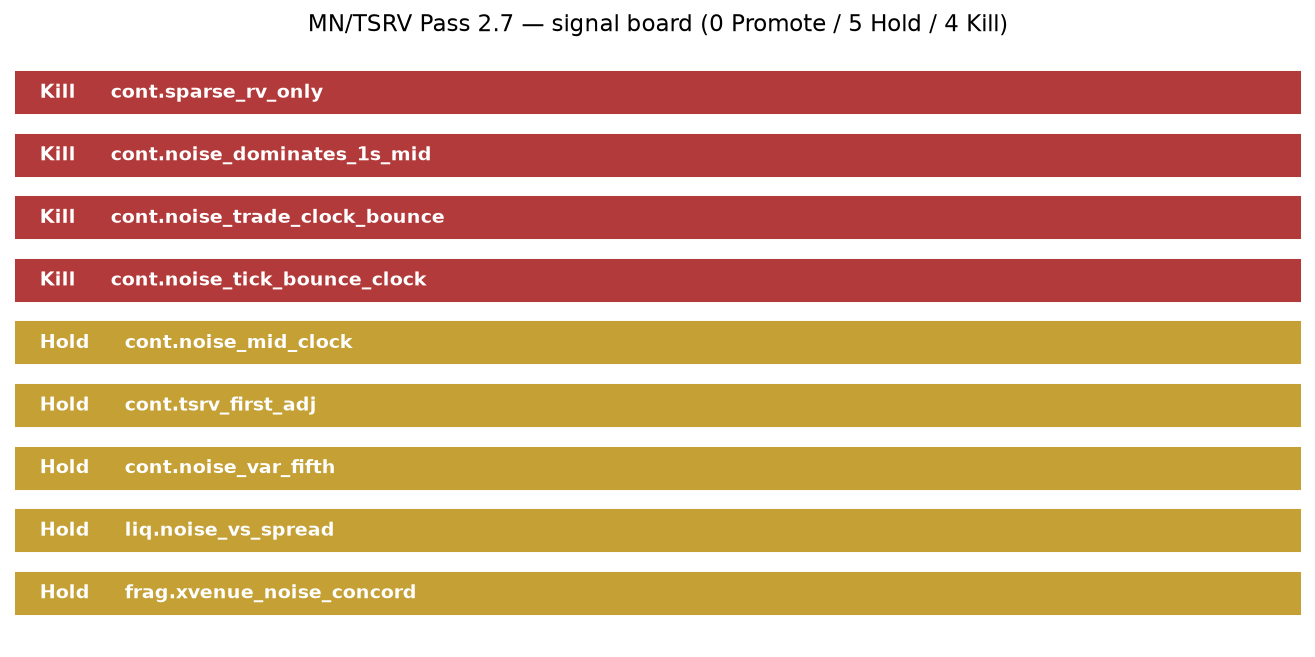

**Gate counts** — `out/desk_synthesis/figs/fig_gate_counts.png`

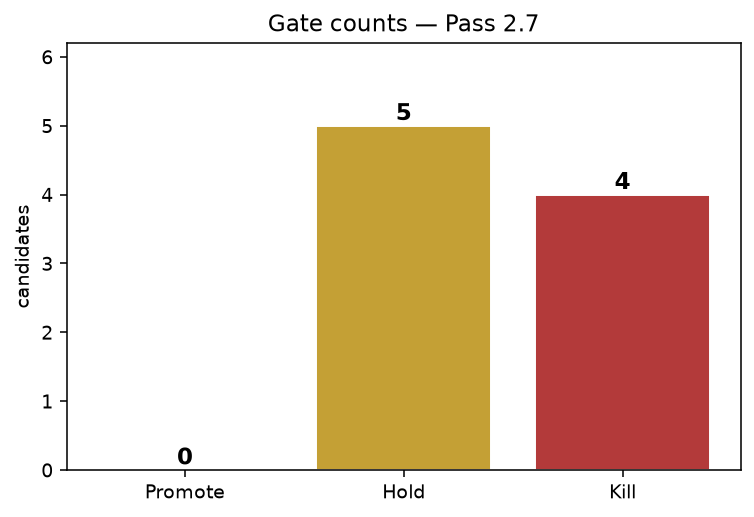

,id,decision,evidence
0,cont.sparse_rv_only,Kill,MC first_adj RMSE ≈ 0.42× fourth
1,cont.noise_dominates_1s_mid,Kill,calendar fifth/fourth med ≪ 1.5
2,cont.noise_trade_clock_bounce,Kill,trade-clock med ≪ 1.5
3,cont.noise_tick_bounce_clock,Kill,CI_lo ≰ 1.5
4,cont.noise_mid_clock,Hold,"dense mid median=2.449 CI=[1.130,3.777] SE=0.6..."
5,cont.tsrv_first_adj,Hold,fragile_rate=0.015 adv_med=5.58e-07 CI=[-5.949...
6,cont.noise_var_fifth,Hold,liquidity proxy only
7,liq.noise_vs_spread,Hold,"ρ=0.016 CI=[-0.169,0.168] shuffle_p=0.8375 blo..."
8,frag.xvenue_noise_concord,Hold,level concordance ≠ edge


counts: {'Hold': 5, 'Kill': 4}


In [2]:
show_fig('signal_board.png', 'Signal board')
show_fig('fig_gate_counts.png', 'Gate counts')

board = [
    ('cont.sparse_rv_only', 'Kill', 'MC first_adj RMSE ≈ 0.42× fourth'),
    ('cont.noise_dominates_1s_mid', 'Kill', 'calendar fifth/fourth med ≪ 1.5'),
    ('cont.noise_trade_clock_bounce', 'Kill', 'trade-clock med ≪ 1.5'),
    ('cont.noise_tick_bounce_clock', 'Kill', 'CI_lo ≰ 1.5'),
    ('cont.noise_mid_clock', 'Hold', bc['mid_clock']['gate']['why']),
    ('cont.tsrv_first_adj', 'Hold', bc['tsrv_oos']['gate']['why'][:160] + '…'),
    ('cont.noise_var_fifth', 'Hold', 'liquidity proxy only'),
    ('liq.noise_vs_spread', 'Hold', gc['spread_falsify']['gate']['why']),
    ('frag.xvenue_noise_concord', 'Hold', 'level concordance ≠ edge'),
]
df = pd.DataFrame(board, columns=['id', 'decision', 'evidence'])
display(df)
print('counts:', df.decision.value_counts().to_dict())


## 2. Pre-registered gates (do not move posts)

| ID | Promote only if |
|----|-----------------|
| `cont.noise_mid_clock` | bootstrap CI_lo of median fifth/fourth **> 1.5** |
| `cont.tsrv_first_adj` | fragile_rate=0 ∧ sparse−tsrv CI_lo>0 early **and** late ∧ n≥20 (**not** MC alone) |
| `liq.noise_vs_spread` | ρ>0 ∧ shuffle p<0.05 ∧ early∧late same sign ∧ n≥20 ∧ CI_lo>0 |
| `cont.sparse_rv_only` | already **Kill** on MC |


## 3. Monte Carlo — Kill sparse RV policy


**Heston MC RMSE ladder** — `out/desk_synthesis/figs/fig_mc_rmse_ladder.png`

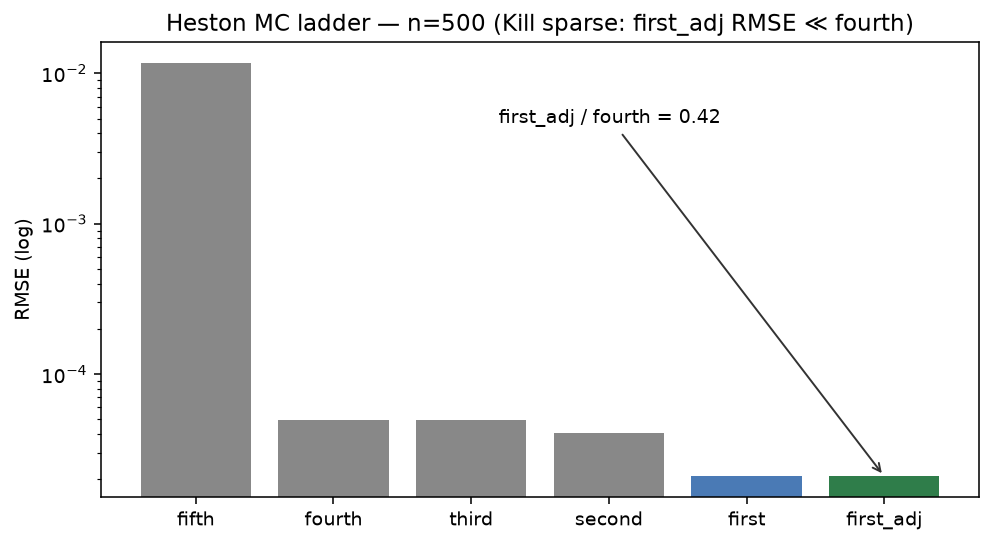

,estimator,bias,rmse,n
0,fifth,0.011695,0.011696,500
1,fourth,0.000038,0.000050,500
2,third,0.000038,0.000050,500
3,second,0.000035,0.000041,500
4,first,-0.000004,0.000021,500
5,first_adj,-0.000003,0.000021,500


first_adj / fourth RMSE = 0.419  -> Kill cont.sparse_rv_only (MC n=500)
pass2 gate: {'cont.sparse_rv_only': 'Kill', 'why': 'first_adj_rmse=2.09213e-05 fourth_rmse=4.98977e-05'}


In [3]:
show_fig('fig_mc_rmse_ladder.png', 'Heston MC RMSE ladder')
est = mc['estimators']
rows = []
for k in ['fifth','fourth','third','second','first','first_adj']:
    e = est[k]
    rows.append({'estimator': k, 'bias': e['bias'], 'rmse': e['rmse'], 'n': e['n']})
display(pd.DataFrame(rows))
ratio = est['first_adj']['rmse'] / est['fourth']['rmse']
print(f"first_adj / fourth RMSE = {ratio:.3f}  -> Kill cont.sparse_rv_only (MC n={mc['n_sims']})")
print('pass2 gate:', p2['cont.sparse_rv_only'])


## 4. Mid-clock — denser TOB, still **Hold**

Pass 2.5 had mid CI ≈ [0.83, 8.17] (n=46). Pass 2.6 expands dense quoted TOB (HL + Deribit + Kraken spot L2) → **n=73**, CI **[1.17, 5.23]**. Point elevated (med≈2.63) but **CI_lo=1.17 < 1.5 gate**.


**Clock medians ± CI95** — `out/desk_synthesis/figs/fig_clock_medians.png`

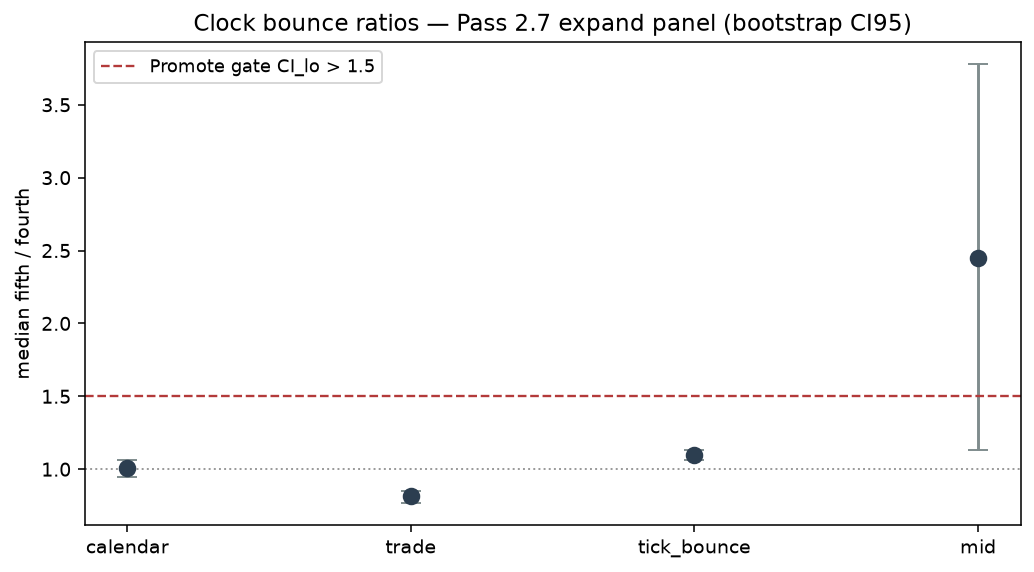

**Venue split** — `out/desk_synthesis/figs/fig_mid_venue_split.png`

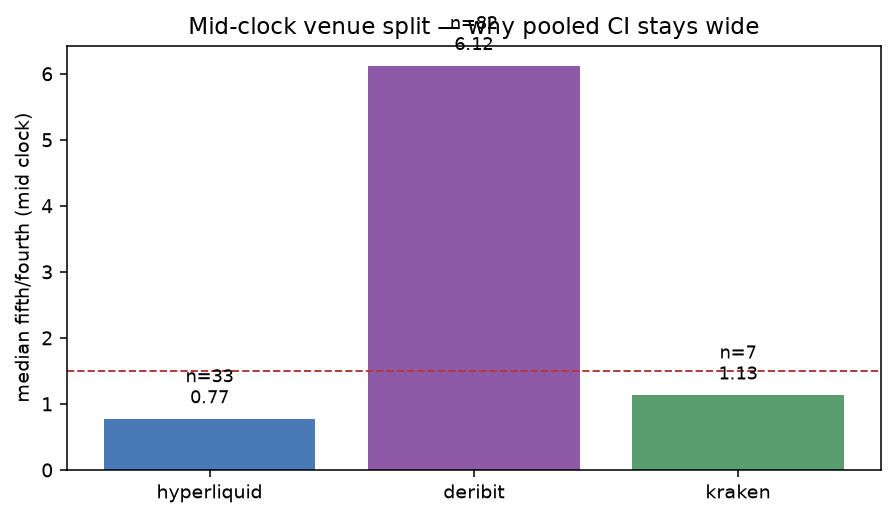

**Ratio histograms** — `out/desk_synthesis/figs/fig_ratio_hist.png`

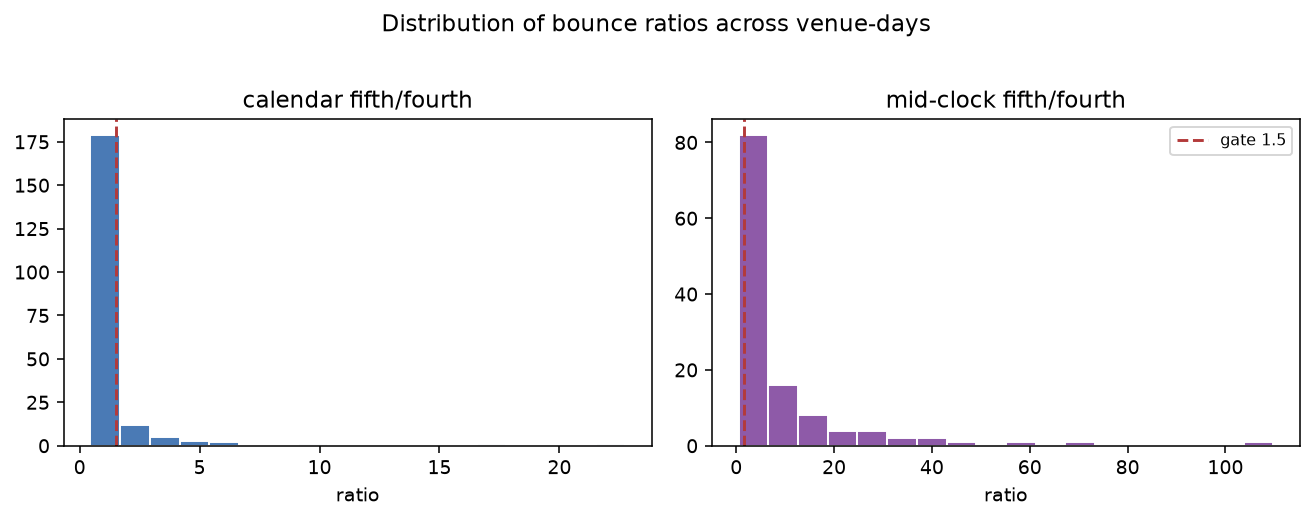

dense mid CI: {'n': 122.0, 'median': 2.4491608334091186, 'mean': 8.607163570387224, 'se': 0.6930382906851165, 'ci95': [1.1304373276015782, 3.7767079464514177]}
gate: {'id': 'cont.noise_mid_clock', 'decision': 'Hold', 'why': 'dense mid median=2.449 CI=[1.130,3.777] SE=0.693 n=122.0 (need CI_lo>1.5)'}
coverage: {
  "hyperliquid": {
    "n_mid": 33,
    "sources": [
      "collector",
      "warehouse:l2_rebuild"
    ],
    "median": 0.7705588921006542
  },
  "deribit": {
    "n_mid": 82,
    "sources": [
      "warehouse:l2_snapshot_level"
    ],
    "median": 6.118723615872716
  },
  "kraken": {
    "n_mid": 7,
    "sources": [
      "warehouse:kraken_spot_l2_rebuild"
    ],
    "median": 1.1304373276015782
  }
}
per_clock decisions:
  Kill     calendar      median=1.006 CI=[0.947337000988308, 1.0647262749347148] n=204 (no bounce domination)
  Kill     trade         median=0.815 CI=[0.7679334356731963, 0.8528358732052667] n=204 (no bounce domination)
  Kill     tick_bounce   median=1.09

In [4]:
show_fig('fig_clock_medians.png', 'Clock medians ± CI95')
show_fig('fig_mid_venue_split.png', 'Venue split')
show_fig('fig_ratio_hist.png', 'Ratio histograms')

md_ci = bc['mid_clock']['mid_dense_ci']
print('dense mid CI:', md_ci)
print('gate:', bc['mid_clock']['gate'])
print('coverage:', json.dumps(bc['mid_clock']['mid_coverage_by_venue'], indent=2))
print('per_clock decisions:')
for k,v in bc['mid_clock']['per_clock'].items():
    print(f"  {v['decision']:7s}  {k:12s}  {v['why']}")


## 5. Tape-level TSRV vs sparse — **Hold** (MC Kill stands)

MC already Kills sparse-only policy. Tape OOS must clear CI_lo>0 on early∧late to Promote `cont.tsrv_first_adj`. It does **not**.


**sparse − first_adj time-split** — `out/desk_synthesis/figs/fig_tsrv_oos.png`

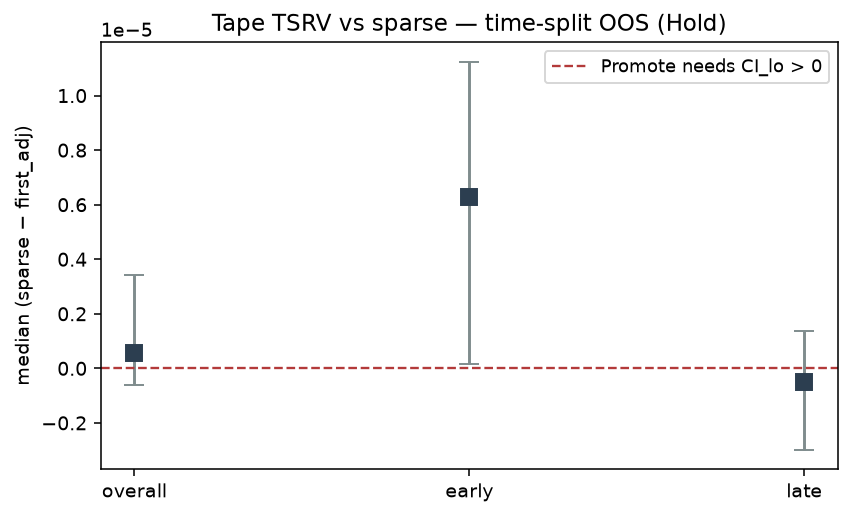

,n,median,mean,se,ci95
overall,204.0,0.000001,0.000003,0.000001,"[-5.949090895340435e-07, 3.4256954437953243e-06]"
early,101.0,0.000006,0.00002,0.000003,"[1.446921174782248e-07, 1.1235763937995365e-05]"
late,103.0,-0.0,-0.000013,0.000001,"[-2.9783714540724274e-06, 1.382499195019151e-06]"


,n,median,mean,se,ci95
overall,204.0,0.984379,1.011291,0.013724,"[0.9628826697099598, 1.0109329144617558]"
early,101.0,0.971732,0.9966,0.011784,"[0.9499918313151521, 0.9984312318255173]"
late,103.0,1.026228,1.025696,0.020888,"[0.9680632587583289, 1.0516421957379292]"


fragile_rate 0.014705882352941176
rolling 5d frac CI_lo>0: 0.06666666666666667
decision: {'id': 'cont.tsrv_first_adj', 'decision': 'Hold', 'why': 'fragile_rate=0.015 adv_med=5.58e-07 CI=[-5.949090895340435e-07, 3.4256954437953243e-06] SE=9.82e-07 earlyCI=[1.446921174782248e-07, 1.1235763937995365e-05] lateCI=[-2.9783714540724274e-06, 1.382499195019151e-06] ratio_med=0.9844 ratioCI=[0.9628826697099598, 1.0109329144617558] roll_ci_lo_pos_frac=0.07 n=204 (MC Kill sparse still stands; Promote needs OOS CI_lo>0 early∧late)'}
MC sparse policy: Kill (unchanged)


In [5]:
show_fig('fig_tsrv_oos.png', 'sparse − first_adj time-split')
ts = bc['tsrv_oos']
display(pd.DataFrame(ts['sparse_minus_tsrv']).T)
display(pd.DataFrame(ts['tsrv_over_sparse']).T)
print('fragile_rate', ts['fragile_rate'])
print('rolling 5d frac CI_lo>0:', ts['rolling_5d']['frac_ci_lo_pos'])
print('decision:', ts['gate'])
print('MC sparse policy:', ts['mc_sparse_policy'])


## 6. Noise vs spread — cross-venue ρ collapses


**Pass 2.5/2.6 join** — `out/desk_synthesis/figs/fig_noise_vs_spread.png`

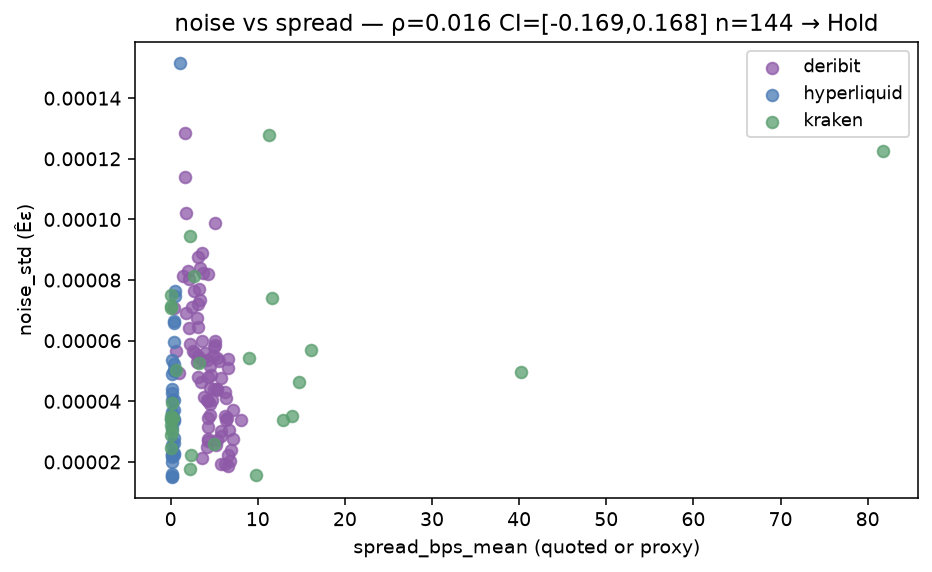

ρ_spread: {'n': 144.0, 'rho': 0.016405433646812958, 'lo': -0.1693348605417571, 'hi': 0.16769039868177793}
ρ_amihud: {'n': 144.0, 'rho': 0.3280564263322884, 'lo': -0.15052065750341612, 'hi': 0.16548378345792134}
shuffle_p 0.8375 block_shuffle_p 0.74625
time_split: {'early_days': ['2026-08-28', '2026-08-29', '2026-08-30', '2026-08-31', '2026-09-01', '2026-09-02', '2026-09-04', '2026-09-05', '2026-09-06', '2026-09-07', '2026-09-08', '2026-09-09', '2026-09-10', '2026-09-11', '2026-09-12', '2026-09-13'], 'late_days': ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-19', '2026-09-20', '2026-09-21', '2026-09-23', '2026-09-24', '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-28', '2026-09-29', '2026-09-30'], 'early': {'n': 59.0, 'rho': -0.2945061367621274, 'lo': -0.2696332554061952, 'hi': 0.23496201052016363}, 'late': {'n': 85.0, 'rho': 0.22202462380300958, 'lo': -0.2085123119015048, 'hi': 0.23700898964236855}, 'same_sign': False}
coverage_by_venue: {'hyperliq

In [6]:
show_fig('fig_noise_vs_spread.png', 'Pass 2.5/2.6 join')
sf = gc['spread_falsify']
print('ρ_spread:', sf['rho_spread'])
print('ρ_amihud:', sf['rho_amihud'])
print('shuffle_p', sf['shuffle_p'], 'block_shuffle_p', sf['block_shuffle_p'])
print('time_split:', sf['time_split'])
print('coverage_by_venue:', sf['coverage_by_venue'])
print('gate:', sf['gate'])


## 7. Kraken TOB inventory (honest)

| Stream | Status |
|--------|--------|
| Futures S3 MRCTCAP1 / public-md | trade/mark/index/funding/OI **only** — no BBO/L2 |
| Spot S3 public-md L2 | **Wired** via `spot|ETH/USD` / `spot|BTC/USD` |
| Futures live REST orderbook | ingest → `out/kraken_futures_tob/` |
| ClickHouse `kraken_md` | unreachable from this host |


**TOB coverage by venue** — `out/desk_synthesis/figs/fig_tob_coverage.png`

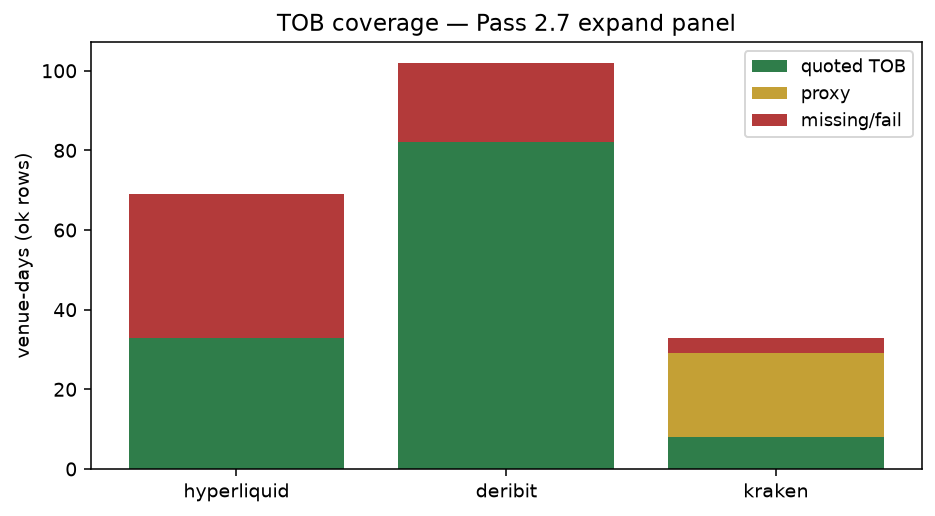

futures ingest sample meta: {'n_rows': 58, 'symbols': ['PF_ETHUSD', 'PF_XBTUSD'], 'path': '/home/dev/srv/ares-microstructure/research/books/mn_tuwrv/out/kraken_futures_tob/20260930/tob_000000.parquet', 'spread_bps_med': 0.3657787277052535, 'ts_first': 1790796801512694451, 'ts_last': 1790796847284207917, 'note': 'Futures quoted TOB from REST; historical S3 archives lack futures L2/BBO.'}
blocker spread sources: {'None': 56, 'warehouse:l2_snapshot_level': 82, 'kraken_proxy': 25, 'warehouse:l2_rebuild': 29, 'warehouse:kraken_spot_l2_rebuild': 8, 'collector': 4}
kraken_days in panel: None


In [7]:
show_fig('fig_tob_coverage.png', 'TOB coverage by venue')
meta = json.loads((OUT/'kraken_futures_tob/20260930/tob_000000.meta.json').read_text())
print('futures ingest sample meta:', meta)
# spot L2 sources in blocker panel
from collections import Counter
srcs = Counter(str((r.get('spread') or {}).get('source')) for r in bc['rows'] if r.get('ok'))
print('blocker spread sources:', dict(srcs))
print('kraken_days in panel:', bc['meta'].get('kraken_days'))


## 8. Desk takeaway

1. **Do not** run sparse-only RV for risk — MC Kill is decisive.  
2. **Do not** Promote mid-clock bounce domination yet — CI_lo still below 1.5; Deribit elevates, HL does not.  
3. **Do not** Promote tape TSRV first_adj on MC alone — OOS advantage CI includes 0.  
4. Noise↔spread is thesis-signed but **not** Promote-grade cross-venue.  
5. Kraken futures historical quoted TOB remains a data-plane gap; spot L2 + live REST ingest are the honest paths.

See chapter notebooks under `chapters/*/`.
